# 02. field3 라벨 품질 게이트

`01_field3_clean_manifest.ipynb`에서 1714개의 clean sample을 만들었지만, 이것은 파일이 정상이라는 뜻일 뿐임.

예를 들어 `001014_mixed_drive_auto_20260501_191729_780`처럼 파일은 정상이고 lane도 1개 있지만, 실제 라벨 선이 노란선을 따라가지 않는 이상한 샘플이 있을 수 있음.

이번 노트북의 목표:

```text
clean sample 1714개 전체를 자동 점수화함
라벨 선이 mask 위에 얼마나 얹혀 있는지 계산함
과도한 곡률/가로 이동/긴 직선 횡단을 잡음
suspicious 샘플을 리뷰용 overlay 폴더로 복사함
최종 학습 후보 manifest와 review 후보 manifest를 저장함
```

주의:

```text
자동 게이트는 완벽한 정답 판정기가 아님.
목표는 확실히 이상한 샘플을 위로 끌어올려 사람이 적게 보게 만드는 것임.
```


In [1]:
from pathlib import Path
import json
import math
import random
import shutil
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
SESSION_ROOT = PROJECT_ROOT / "10_experiments" / "10_lane_autolabel_collection" / "outputs" / "20260501_191218_lane_autolabel_drive"
EXPERIMENT_ROOT = PROJECT_ROOT / "10_experiments" / "11_clrkdnet_precision_tuning"
IN_DIR = EXPERIMENT_ROOT / "review_outputs" / "01_field3_clean_manifest"
OUT_DIR = EXPERIMENT_ROOT / "review_outputs" / "02_field3_label_quality_gate"
REVIEW_DIR = OUT_DIR / "review_overlays"
for p in [OUT_DIR, REVIEW_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CLEAN_MANIFEST = IN_DIR / "field3_clean_manifest.csv"
print('CLEAN_MANIFEST:', CLEAN_MANIFEST, CLEAN_MANIFEST.exists())
print('SESSION_ROOT:', SESSION_ROOT)
print('OUT_DIR:', OUT_DIR)


CLEAN_MANIFEST: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\01_field3_clean_manifest\field3_clean_manifest.csv True
SESSION_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\10_lane_autolabel_collection\outputs\20260501_191218_lane_autolabel_drive
OUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate


## 1. clean manifest 로드

`01`의 결과를 입력으로 사용함.


In [2]:
clean_df = pd.read_csv(CLEAN_MANIFEST)
print('clean rows:', len(clean_df))
print('columns:', list(clean_df.columns))
display(clean_df.head())
display(clean_df['lane_count'].value_counts().sort_index().rename('count').to_frame())


clean rows: 1714
columns: ['stem', 'frame_idx', 'domain', 'scene', 'status', 'exclude_reason', 'raw', 'lines', 'mask', 'overlay', 'overlay_status', 'raw_size', 'label_size', 'mask_size', 'overlay_size', 'lane_count', 'point_total', 'point_min', 'point_max', 'y_span_median', 'x_min', 'x_max', 'y_min', 'y_max', 'block_id', 'split_suggested']


,stem,frame_idx,domain,scene,status,exclude_reason,raw,lines,mask,overlay,...,point_total,point_min,point_max,y_span_median,x_min,x_max,y_min,y_max,block_id,split_suggested
0,000000_mixed_drive_auto_20260501_191234_792,0,field3_drive,field_drive,clean,NaN,raw/field_drive/000000_mixed_drive_auto_202605...,labels/field_drive/000000_mixed_drive_auto_202...,masks/field_drive/000000_mixed_drive_auto_2026...,overlays/usable/field_drive/000000_mixed_drive...,...,164,76,88,486.0,2.99,1184.83,449.0,971.0,0,train
1,000001_mixed_drive_auto_20260501_191235_013,1,field3_drive,field_drive,clean,NaN,raw/field_drive/000001_mixed_drive_auto_202605...,labels/field_drive/000001_mixed_drive_auto_202...,masks/field_drive/000001_mixed_drive_auto_2026...,overlays/usable/field_drive/000001_mixed_drive...,...,164,76,88,486.0,2.96,1184.99,449.0,971.0,0,train
2,000002_mixed_drive_auto_20260501_191235_241,2,field3_drive,field_drive,clean,NaN,raw/field_drive/000002_mixed_drive_auto_202605...,labels/field_drive/000002_mixed_drive_auto_202...,masks/field_drive/000002_mixed_drive_auto_2026...,overlays/usable/field_drive/000002_mixed_drive...,...,164,76,88,486.0,2.95,1184.89,449.0,971.0,0,train
3,000003_mixed_drive_auto_20260501_191235_477,3,field3_drive,field_drive,clean,NaN,raw/field_drive/000003_mixed_drive_auto_202605...,labels/field_drive/000003_mixed_drive_auto_202...,masks/field_drive/000003_mixed_drive_auto_2026...,overlays/usable/field_drive/000003_mixed_drive...,...,164,76,88,486.0,2.88,1184.97,449.0,971.0,0,train
4,000004_mixed_drive_auto_20260501_191235_723,4,field3_drive,field_drive,clean,NaN,raw/field_drive/000004_mixed_drive_auto_202605...,labels/field_drive/000004_mixed_drive_auto_202...,masks/field_drive/000004_mixed_drive_auto_2026...,overlays/usable/field_drive/000004_mixed_drive...,...,164,76,88,486.0,2.91,1184.85,449.0,971.0,0,train


,count
lane_count,
1,464
2,1250


## 2. 라벨 품질 점수 설계

이번 자동 점수는 주로 세 가지를 봄.

### 2.1 mask support

`.lines.txt`의 점들이 실제 HSV mask 위에 놓이는지 확인함.

```text
mask 위에 있으면 좋은 라벨일 가능성이 큼
mask에서 많이 벗어나면 001014 같은 이상 라벨일 가능성이 큼
```

### 2.2 geometry outlier

라벨 선 하나의 x 이동/곡률/길이가 과도하면 의심함.

```text
x_span이 너무 큼
두 끝점이 화면을 크게 가로지름
곡률이 과함
```

### 2.3 lane position sanity

우리 주행 관점에서는 화면 아래쪽 가까운 구간에서 lane 위치가 중요함.

```text
아래쪽에서 x가 너무 비정상적으로 튐
두 lane 간격이 말이 안 됨
```

단, 교차로/커브는 원래 어렵기 때문에 너무 공격적으로 reject하지 않음.  
자동 결과는 `usable_auto`, `review_needed`, `reject_auto`로 나눔.


In [3]:
def resolve(rel_path):
    return SESSION_ROOT / str(rel_path).replace('/', '\\')

def parse_lines_file(path: Path):
    lanes = []
    if path is None or not path.exists() or path.stat().st_size == 0:
        return lanes
    for line in path.read_text(encoding='utf-8', errors='ignore').splitlines():
        vals = []
        for part in line.strip().split():
            try:
                vals.append(float(part))
            except ValueError:
                pass
        pts = []
        for i in range(0, len(vals) - 1, 2):
            x, y = vals[i], vals[i + 1]
            if x >= 0 and y >= 0:
                pts.append((float(x), float(y)))
        if len(pts) > 2:
            lanes.append(sorted(set(pts), key=lambda p: p[1]))
    return lanes

def sample_mask_near(mask, x, y, radius=4):
    h, w = mask.shape[:2]
    xi, yi = int(round(x)), int(round(y))
    x0, x1 = max(0, xi - radius), min(w, xi + radius + 1)
    y0, y1 = max(0, yi - radius), min(h, yi + radius + 1)
    if x0 >= x1 or y0 >= y1:
        return 0
    return 1 if np.any(mask[y0:y1, x0:x1] > 0) else 0

def lane_curvature_score(points):
    if len(points) < 5:
        return 0.0
    ys = np.array([p[1] for p in points], dtype=np.float32)
    xs = np.array([p[0] for p in points], dtype=np.float32)
    if np.ptp(ys) < 1:
        return 0.0
    # Fit x as function of normalized y. Quadratic coefficient magnitude is a rough curvature proxy.
    yn = (ys - ys.mean()) / (ys.std() + 1e-6)
    try:
        coef = np.polyfit(yn, xs, deg=2)
        return float(abs(coef[0]))
    except Exception:
        return 0.0

def lane_endpoint_chord(points):
    if len(points) < 2:
        return 0.0
    x0, y0 = points[0]
    x1, y1 = points[-1]
    return float(math.hypot(x1 - x0, y1 - y0))

def compute_quality(row):
    raw_path = resolve(row['raw'])
    mask_path = resolve(row['mask'])
    line_path = resolve(row['lines'])
    lanes = parse_lines_file(line_path)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        mask = np.zeros((972, 1296), dtype=np.uint8)

    per_lane = []
    all_points = []
    for lane in lanes:
        support = [sample_mask_near(mask, x, y, radius=5) for x, y in lane]
        xs = [p[0] for p in lane]
        ys = [p[1] for p in lane]
        all_points.extend(lane)
        per_lane.append({
            'points': len(lane),
            'mask_support_ratio': float(np.mean(support)) if support else 0.0,
            'x_span': float(max(xs) - min(xs)) if xs else 0.0,
            'y_span': float(max(ys) - min(ys)) if ys else 0.0,
            'curvature': lane_curvature_score(lane),
            'chord': lane_endpoint_chord(lane),
            'bottom_x': float(xs[-1]) if xs else np.nan,
            'top_x': float(xs[0]) if xs else np.nan,
        })

    if per_lane:
        mask_support_min = min(v['mask_support_ratio'] for v in per_lane)
        mask_support_mean = float(np.mean([v['mask_support_ratio'] for v in per_lane]))
        x_span_max = max(v['x_span'] for v in per_lane)
        y_span_max = max(v['y_span'] for v in per_lane)
        curvature_max = max(v['curvature'] for v in per_lane)
        chord_max = max(v['chord'] for v in per_lane)
    else:
        mask_support_min = 0.0
        mask_support_mean = 0.0
        x_span_max = 0.0
        y_span_max = 0.0
        curvature_max = 0.0
        chord_max = 0.0

    reasons = []
    # Conservative gates. These are intentionally review-oriented, not final truth.
    if mask_support_min < 0.45:
        reasons.append('low_mask_support')
    if mask_support_mean < 0.65:
        reasons.append('low_mean_support')
    if x_span_max > 850:
        reasons.append('huge_x_span')
    if curvature_max > 180:
        reasons.append('high_curvature')
    if chord_max > 1050:
        reasons.append('long_chord')
    if int(row.lane_count) == 1 and x_span_max > 700 and mask_support_min < 0.7:
        reasons.append('suspicious_one_lane_crossing')

    # Score: higher means more suspicious.
    score = 0.0
    score += max(0.0, 0.80 - mask_support_min) * 120
    score += max(0.0, 0.85 - mask_support_mean) * 60
    score += max(0.0, x_span_max - 550) / 8
    score += max(0.0, curvature_max - 80) / 3
    score += max(0.0, chord_max - 800) / 12
    score += len(reasons) * 15

    if len(reasons) >= 3 or score >= 95:
        quality_status = 'reject_auto'
    elif len(reasons) >= 1 or score >= 45:
        quality_status = 'review_needed'
    else:
        quality_status = 'usable_auto'

    return {
        'mask_support_min': mask_support_min,
        'mask_support_mean': mask_support_mean,
        'x_span_max': x_span_max,
        'y_span_max': y_span_max,
        'curvature_max': curvature_max,
        'chord_max': chord_max,
        'quality_score': float(score),
        'quality_status': quality_status,
        'quality_reasons': '|'.join(reasons),
    }


## 3. 전체 clean sample 점수화

1714개 전체를 돌림.

이미지 inference가 아니라 mask/label 계산이라 빠른 편임.


In [4]:
quality_rows = []
for i, row in clean_df.iterrows():
    if i % 250 == 0:
        print(f'quality {i}/{len(clean_df)}')
    q = compute_quality(row)
    quality_rows.append(q)

quality_df = pd.concat([clean_df.reset_index(drop=True), pd.DataFrame(quality_rows)], axis=1)
print('done:', len(quality_df))
display(quality_df['quality_status'].value_counts().rename('count').to_frame())
display(quality_df['quality_reasons'].value_counts().head(20).rename('count').to_frame())
display(quality_df.sort_values('quality_score', ascending=False).head(20)[[
    'stem', 'lane_count', 'quality_status', 'quality_score', 'quality_reasons',
    'mask_support_min', 'mask_support_mean', 'x_span_max', 'curvature_max', 'chord_max', 'overlay'
]])


quality 0/1714
quality 250/1714
quality 500/1714
quality 750/1714
quality 1000/1714
quality 1250/1714
quality 1500/1714
done: 1714


,count
quality_status,
usable_auto,1383
reject_auto,190
review_needed,141


,count
quality_reasons,
,1424
huge_x_span|long_chord,157
huge_x_span,98
low_mask_support,9
low_mean_support|huge_x_span|high_curvature|suspicious_one_lane_crossing,9
low_mask_support|low_mean_support|huge_x_span|high_curvature|suspicious_one_lane_crossing,3
high_curvature,3
suspicious_one_lane_crossing,2
low_mean_support|high_curvature|suspicious_one_lane_crossing,2


,stem,lane_count,quality_status,quality_score,quality_reasons,mask_support_min,mask_support_mean,x_span_max,curvature_max,chord_max,overlay
1006,001013_mixed_drive_auto_20260501_191729_549,1,reject_auto,249.016153,low_mask_support|low_mean_support|huge_x_span|...,0.447059,0.447059,944.30,254.597723,627.161512,overlays/usable/field_drive/001013_mixed_drive...
1497,001513_mixed_drive_auto_20260501_191929_281,1,reject_auto,247.799803,low_mean_support|huge_x_span|high_curvature|su...,0.590909,0.590909,1027.12,342.570317,523.914652,overlays/usable/field_drive/001513_mixed_drive...
1279,001290_mixed_drive_auto_20260501_191837_429,1,reject_auto,241.032237,low_mask_support|low_mean_support|huge_x_span|...,0.397260,0.397260,900.80,220.067260,640.890808,overlays/usable/field_drive/001290_mixed_drive...
1494,001510_mixed_drive_auto_20260501_191928_587,1,reject_auto,234.252274,low_mean_support|huge_x_span|high_curvature|su...,0.525424,0.525424,973.20,286.785635,441.792382,overlays/usable/field_drive/001510_mixed_drive...
1007,001014_mixed_drive_auto_20260501_191729_780,1,reject_auto,233.470134,low_mean_support|huge_x_span|high_curvature|su...,0.534091,0.534091,952.33,296.945744,545.847759,overlays/usable/field_drive/001014_mixed_drive...
1005,001012_mixed_drive_auto_20260501_191729_325,1,reject_auto,231.649310,low_mask_support|low_mean_support|huge_x_span|...,0.375000,0.375000,867.29,192.464180,720.697962,overlays/usable/field_drive/001012_mixed_drive...
1496,001512_mixed_drive_auto_20260501_191929_032,1,reject_auto,226.859833,low_mean_support|huge_x_span|high_curvature|su...,0.579710,0.579710,988.59,288.151728,497.998798,overlays/usable/field_drive/001512_mixed_drive...
1495,001511_mixed_drive_auto_20260501_191928_829,1,reject_auto,226.331669,low_mean_support|huge_x_span|high_curvature|su...,0.562500,0.562500,924.11,301.453757,389.539076,overlays/usable/field_drive/001511_mixed_drive...
1135,001143_mixed_drive_auto_20260501_191759_152,1,reject_auto,225.622539,low_mean_support|huge_x_span|high_curvature|su...,0.472727,0.472727,868.54,271.687844,361.952790,overlays/usable/field_drive/001143_mixed_drive...
1280,001291_mixed_drive_auto_20260501_191837_647,1,reject_auto,223.354613,low_mean_support|huge_x_span|high_curvature|su...,0.512821,0.512821,899.94,274.759415,498.654713,overlays/usable/field_drive/001291_mixed_drive...


## 4. 001014 케이스 확인

문제가 있다고 확인한 `001014...`가 품질 게이트에서 잘 끌려 올라오는지 확인함.


In [5]:
case = quality_df[quality_df['stem'].str.startswith('001014')]
display(case[[
    'stem', 'quality_status', 'quality_score', 'quality_reasons',
    'mask_support_min', 'mask_support_mean', 'x_span_max', 'curvature_max', 'chord_max', 'overlay'
]])


,stem,quality_status,quality_score,quality_reasons,mask_support_min,mask_support_mean,x_span_max,curvature_max,chord_max,overlay
1007,001014_mixed_drive_auto_20260501_191729_780,reject_auto,233.470134,low_mean_support|huge_x_span|high_curvature|su...,0.534091,0.534091,952.33,296.945744,545.847759,overlays/usable/field_drive/001014_mixed_drive...


## 5. 리뷰용 overlay 복사

사람이 볼 양을 줄이기 위해 아래 폴더에 overlay를 복사함.

```text
review_overlays/reject_auto
review_overlays/review_needed_top80
review_overlays/usable_auto_sample
```

일단 자동 reject는 바로 학습에서 제외 후보로 보고, review_needed는 사람이 일부 확인함.


In [6]:
def copy_overlays(df, target_dir, limit=None):
    target_dir = Path(target_dir)
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    rows = df if limit is None else df.head(limit)
    copied = 0
    for _, row in rows.iterrows():
        src = resolve(row['overlay'])
        if src.exists() and src.stat().st_size > 0:
            dst = target_dir / f"{int(row.quality_score):03d}__{row.stem}.jpg"
            shutil.copy2(src, dst)
            copied += 1
    return copied

reject_df = quality_df[quality_df['quality_status'] == 'reject_auto'].sort_values('quality_score', ascending=False)
review_df = quality_df[quality_df['quality_status'] == 'review_needed'].sort_values('quality_score', ascending=False)
usable_df = quality_df[quality_df['quality_status'] == 'usable_auto'].sort_values('quality_score', ascending=False)

copied_reject = copy_overlays(reject_df, REVIEW_DIR / 'reject_auto')
copied_review = copy_overlays(review_df, REVIEW_DIR / 'review_needed_top80', limit=80)
copied_usable = copy_overlays(usable_df.sample(min(80, len(usable_df)), random_state=21), REVIEW_DIR / 'usable_auto_sample')

print('copied reject_auto:', copied_reject)
print('copied review_needed_top80:', copied_review)
print('copied usable_auto_sample:', copied_usable)
print('review dir:', REVIEW_DIR)


copied reject_auto: 190
copied review_needed_top80: 80
copied usable_auto_sample: 80
review dir: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate\review_overlays


## 6. 상위 suspicious 샘플 시각 확인

노트북 안에서도 상위 suspicious 샘플을 바로 확인함.


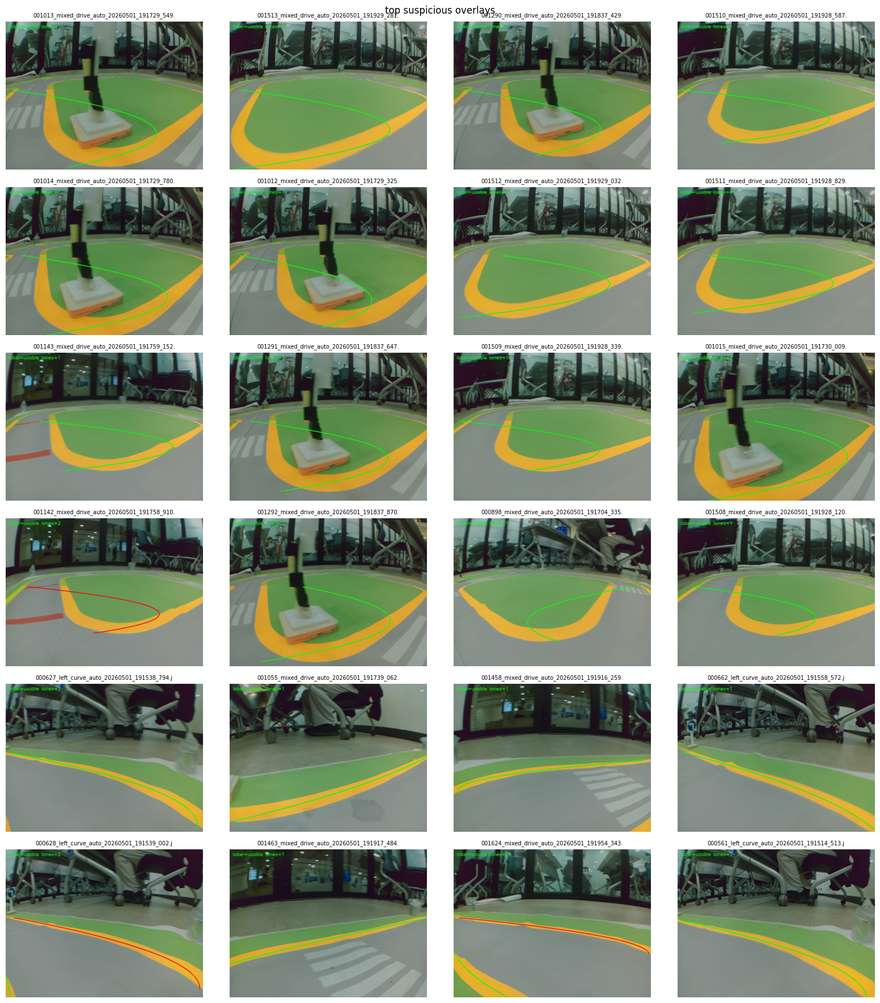

In [7]:
def show_image_grid(paths, title, cols=4, max_images=16):
    paths = [Path(p) for p in paths if p]
    paths = paths[:max_images]
    if not paths:
        print('no images:', title)
        return
    rows = math.ceil(len(paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, path in zip(axes, paths):
        img = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img is None:
            ax.set_title('read fail')
            ax.axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(path.name[:44], fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

suspicious_paths = [resolve(p) for p in quality_df.sort_values('quality_score', ascending=False).head(24)['overlay']]
show_image_grid(suspicious_paths, 'top suspicious overlays', cols=4, max_images=24)


## 7. 최종 manifest 후보 저장

현재 자동 정책:

```text
reject_auto는 학습에서 제외
review_needed와 usable_auto는 일단 후보로 유지
```

단, 다음 단계에서 사람이 `review_overlays`를 보고 blacklist를 추가할 수 있음.

저장 파일:

```text
field3_quality_scored_manifest.csv
field3_train_candidate_auto.csv
field3_reject_auto.csv
field3_review_needed.csv
field3_quality_summary.json
```


In [8]:
scored_path = OUT_DIR / 'field3_quality_scored_manifest.csv'
train_candidate_path = OUT_DIR / 'field3_train_candidate_auto.csv'
reject_auto_path = OUT_DIR / 'field3_reject_auto.csv'
review_needed_path = OUT_DIR / 'field3_review_needed.csv'
summary_path = OUT_DIR / 'field3_quality_summary.json'

train_candidate_df = quality_df[quality_df['quality_status'] != 'reject_auto'].copy()
reject_auto_df = quality_df[quality_df['quality_status'] == 'reject_auto'].copy()
review_needed_df = quality_df[quality_df['quality_status'] == 'review_needed'].copy()

quality_df.to_csv(scored_path, index=False, encoding='utf-8-sig')
train_candidate_df.to_csv(train_candidate_path, index=False, encoding='utf-8-sig')
reject_auto_df.to_csv(reject_auto_path, index=False, encoding='utf-8-sig')
review_needed_df.to_csv(review_needed_path, index=False, encoding='utf-8-sig')

summary = {
    'input_clean_rows': int(len(clean_df)),
    'train_candidate_auto_rows': int(len(train_candidate_df)),
    'reject_auto_rows': int(len(reject_auto_df)),
    'review_needed_rows': int(len(review_needed_df)),
    'quality_status_counts': {str(k): int(v) for k, v in quality_df['quality_status'].value_counts().items()},
    'quality_reason_counts_top20': {str(k): int(v) for k, v in quality_df['quality_reasons'].value_counts().head(20).items()},
    'notebook_policy': 'reject_auto excluded; review_needed kept for now but copied for manual review',
    'scored_manifest': str(scored_path),
    'train_candidate_auto_manifest': str(train_candidate_path),
    'reject_auto_manifest': str(reject_auto_path),
    'review_needed_manifest': str(review_needed_path),
    'review_overlays_dir': str(REVIEW_DIR),
}
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print('saved:', scored_path)
print('saved:', train_candidate_path)
print('saved:', reject_auto_path)
print('saved:', review_needed_path)
print('saved:', summary_path)
print(json.dumps(summary, indent=2, ensure_ascii=False))


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate\field3_quality_scored_manifest.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate\field3_train_candidate_auto.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate\field3_reject_auto.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate\field3_review_needed.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate\field3_quality_summary.json
{
  "input_clean_rows": 1714,
  "train_candidat

## 8. 노트북 실행 후 메모

아직 실행 전임.

실행 후 확인할 것:

```text
001014이 reject_auto 또는 review_needed로 올라오는가
reject_auto 개수가 너무 많거나 적지 않은가
review_needed_top80 폴더를 봤을 때 실제 이상 라벨이 많은가
최종 학습 후보를 train_candidate_auto로 둘지, 수동 blacklist를 추가할지
```


### review_needed_top80
- 072__001140_mixed_drive_auto_20260501_191758_431
- 077__001501_mixed_drive_auto_20260501_191926_534
- 077__001502_mixed_drive_auto_20260501_191926_779
- 079__001145_mixed_drive_auto_20260501_191759_650
- 081__001011_mixed_drive_auto_20260501_191729_101
- 088__001141_mixed_drive_auto_20260501_191758_684

### reject_auto
- 098__001017_mixed_drive_auto_20260501_191730_446
- 098__001503_mixed_drive_auto_20260501_191926_988
- 107__001294_mixed_drive_auto_20260501_191838_331
- 108__000897_mixed_drive_auto_20260501_191704_093
- 113__001507_mixed_drive_auto_20260501_191927_876
- 114__001289_mixed_drive_auto_20260501_191837_184
- 115__001504_mixed_drive_auto_20260501_191927_223
- 116__001506_mixed_drive_auto_20260501_191927_633
- 129__001293_mixed_drive_auto_20260501_191838_111
- 131__001505_mixed_drive_auto_20260501_191927_421
- 136__000899_mixed_drive_auto_20260501_191704_586
- 153__001016_mixed_drive_auto_20260501_191730_218
- 161__001144_mixed_drive_auto_20260501_191759_405
- 176__001508_mixed_drive_auto_20260501_191928_120
- 178__000898_mixed_drive_auto_20260501_191704_335
- 180__001292_mixed_drive_auto_20260501_191837_870
- 184__001142_mixed_drive_auto_20260501_191758_910
- 196__001015_mixed_drive_auto_20260501_191730_009
- 220__001509_mixed_drive_auto_20260501_191928_339
- 223__001291_mixed_drive_auto_20260501_191837_647
- 225__001143_mixed_drive_auto_20260501_191759_152
- 226__001511_mixed_drive_auto_20260501_191928_829
- 226__001512_mixed_drive_auto_20260501_191929_032
- 231__001012_mixed_drive_auto_20260501_191729_325
- 233__001014_mixed_drive_auto_20260501_191729_780
- 234__001510_mixed_drive_auto_20260501_191928_587
- 241__001290_mixed_drive_auto_20260501_191837_429
- 247__001513_mixed_drive_auto_20260501_191929_281
- 249__001013_mixed_drive_auto_20260501_191729_549

## 9. 수동 확인 기반 최종 학습 후보 확정

자동 gate의 `reject_auto`는 실제로는 "무조건 제외"가 아니라 "우선 확인해야 하는 후보"에 가까웠음.

직접 `reject_auto`와 `review_needed_top80`를 확인한 결과, 아래 파일만 최종 제외 대상으로 확정함. 나머지 `reject_auto`는 곡선/한쪽 차선 hard case일 수 있으므로 다시 학습 후보로 복구함.

정책:

```text
최종 제외 = manual blacklist
최종 학습 후보 = clean 1714장 - manual blacklist 35장 = 1679장
자동 reject_auto 중 수동 blacklist가 아닌 파일은 복구
```


In [9]:
from pathlib import Path
import json
import pandas as pd

OUT_DIR = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\02_field3_label_quality_gate")

MANUAL_REJECT_BASENAMES = [
    '001140_mixed_drive_auto_20260501_191758_431.jpg',
    '001501_mixed_drive_auto_20260501_191926_534.jpg',
    '001502_mixed_drive_auto_20260501_191926_779.jpg',
    '001145_mixed_drive_auto_20260501_191759_650.jpg',
    '001011_mixed_drive_auto_20260501_191729_101.jpg',
    '001141_mixed_drive_auto_20260501_191758_684.jpg',
    '001017_mixed_drive_auto_20260501_191730_446.jpg',
    '001503_mixed_drive_auto_20260501_191926_988.jpg',
    '001294_mixed_drive_auto_20260501_191838_331.jpg',
    '000897_mixed_drive_auto_20260501_191704_093.jpg',
    '001507_mixed_drive_auto_20260501_191927_876.jpg',
    '001289_mixed_drive_auto_20260501_191837_184.jpg',
    '001504_mixed_drive_auto_20260501_191927_223.jpg',
    '001506_mixed_drive_auto_20260501_191927_633.jpg',
    '001293_mixed_drive_auto_20260501_191838_111.jpg',
    '001505_mixed_drive_auto_20260501_191927_421.jpg',
    '000899_mixed_drive_auto_20260501_191704_586.jpg',
    '001016_mixed_drive_auto_20260501_191730_218.jpg',
    '001144_mixed_drive_auto_20260501_191759_405.jpg',
    '001508_mixed_drive_auto_20260501_191928_120.jpg',
    '000898_mixed_drive_auto_20260501_191704_335.jpg',
    '001292_mixed_drive_auto_20260501_191837_870.jpg',
    '001142_mixed_drive_auto_20260501_191758_910.jpg',
    '001015_mixed_drive_auto_20260501_191730_009.jpg',
    '001509_mixed_drive_auto_20260501_191928_339.jpg',
    '001291_mixed_drive_auto_20260501_191837_647.jpg',
    '001143_mixed_drive_auto_20260501_191759_152.jpg',
    '001511_mixed_drive_auto_20260501_191928_829.jpg',
    '001512_mixed_drive_auto_20260501_191929_032.jpg',
    '001012_mixed_drive_auto_20260501_191729_325.jpg',
    '001014_mixed_drive_auto_20260501_191729_780.jpg',
    '001510_mixed_drive_auto_20260501_191928_587.jpg',
    '001290_mixed_drive_auto_20260501_191837_429.jpg',
    '001513_mixed_drive_auto_20260501_191929_281.jpg',
    '001013_mixed_drive_auto_20260501_191729_549.jpg',
]
MANUAL_REJECT_BASENAMES = list(dict.fromkeys(MANUAL_REJECT_BASENAMES))

quality_df = pd.read_csv(OUT_DIR / 'field3_quality_scored_manifest.csv')
quality_df['raw_base'] = quality_df['raw'].map(lambda p: Path(str(p)).name)

missing = sorted(set(MANUAL_REJECT_BASENAMES) - set(quality_df['raw_base']))
assert not missing, missing

manual_reject_df = quality_df[quality_df['raw_base'].isin(MANUAL_REJECT_BASENAMES)].copy()
train_candidate_manual_df = quality_df[~quality_df['raw_base'].isin(MANUAL_REJECT_BASENAMES)].copy()
recovered_auto_reject_df = quality_df[(quality_df['quality_status'] == 'reject_auto') & (~quality_df['raw_base'].isin(MANUAL_REJECT_BASENAMES))].copy()

manual_reject_path = OUT_DIR / 'field3_manual_reject.csv'
manual_train_path = OUT_DIR / 'field3_train_candidate_manual.csv'
recovered_path = OUT_DIR / 'field3_recovered_auto_reject.csv'
manual_names_path = OUT_DIR / 'field3_manual_reject_basenames.txt'
manual_summary_path = OUT_DIR / 'field3_manual_policy_summary.json'

manual_reject_df.to_csv(manual_reject_path, index=False, encoding='utf-8-sig')
train_candidate_manual_df.to_csv(manual_train_path, index=False, encoding='utf-8-sig')
recovered_auto_reject_df.to_csv(recovered_path, index=False, encoding='utf-8-sig')
manual_names_path.write_text('\n'.join(MANUAL_REJECT_BASENAMES) + '\n', encoding='utf-8')

manual_summary = {
    'policy': 'manual blacklist only; auto reject is used as review priority, not final exclusion',
    'input_clean_rows': int(len(quality_df)),
    'manual_reject_rows': int(len(manual_reject_df)),
    'train_candidate_manual_rows': int(len(train_candidate_manual_df)),
    'auto_reject_rows_before_manual_policy': int((quality_df['quality_status'] == 'reject_auto').sum()),
    'manual_reject_from_auto_reject': int((manual_reject_df['quality_status'] == 'reject_auto').sum()),
    'manual_reject_from_review_needed': int((manual_reject_df['quality_status'] == 'review_needed').sum()),
    'recovered_auto_reject_rows': int(len(recovered_auto_reject_df)),
    'manual_reject_manifest': str(manual_reject_path),
    'train_candidate_manual_manifest': str(manual_train_path),
    'recovered_auto_reject_manifest': str(recovered_path),
    'manual_reject_basenames': str(manual_names_path),
}
manual_summary_path.write_text(json.dumps(manual_summary, indent=2, ensure_ascii=False), encoding='utf-8')

print(json.dumps(manual_summary, indent=2, ensure_ascii=False))
display(manual_reject_df[['raw_base', 'quality_status', 'quality_reasons', 'lane_count', 'mask_support_min', 'mask_support_mean', 'x_span_max', 'curvature_max']])


{
  "policy": "manual blacklist only; auto reject is used as review priority, not final exclusion",
  "input_clean_rows": 1714,
  "manual_reject_rows": 35,
  "train_candidate_manual_rows": 1679,
  "auto_reject_rows_before_manual_policy": 190,
  "manual_reject_from_auto_reject": 29,
  "manual_reject_from_review_needed": 6,
  "recovered_auto_reject_rows": 161,
  "manual_reject_manifest": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\review_outputs\\02_field3_label_quality_gate\\field3_manual_reject.csv",
  "train_candidate_manual_manifest": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\review_outputs\\02_field3_label_quality_gate\\field3_train_candidate_manual.csv",
  "recovered_auto_reject_manifest": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\11_clrkdnet_precision_tuning\\review_outputs\\02_field3_lab

,raw_base,quality_status,quality_reasons,lane_count,mask_support_min,mask_support_mean,x_span_max,curvature_max
894,000897_mixed_drive_auto_20260501_191704_093.jpg,reject_auto,low_mask_support|low_mean_support,1,0.381818,0.381818,476.92,29.093963
895,000898_mixed_drive_auto_20260501_191704_335.jpg,reject_auto,low_mask_support|low_mean_support|suspicious_o...,1,0.295082,0.295082,700.36,142.588467
896,000899_mixed_drive_auto_20260501_191704_586.jpg,reject_auto,low_mean_support|high_curvature,1,0.597015,0.597015,680.87,230.368682
1004,001011_mixed_drive_auto_20260501_191729_101.jpg,review_needed,low_mask_support,2,0.413333,0.706667,638.45,82.612488
1005,001012_mixed_drive_auto_20260501_191729_325.jpg,reject_auto,low_mask_support|low_mean_support|huge_x_span|...,1,0.375000,0.375000,867.29,192.464180
1006,001013_mixed_drive_auto_20260501_191729_549.jpg,reject_auto,low_mask_support|low_mean_support|huge_x_span|...,1,0.447059,0.447059,944.30,254.597723
1007,001014_mixed_drive_auto_20260501_191729_780.jpg,reject_auto,low_mean_support|huge_x_span|high_curvature|su...,1,0.534091,0.534091,952.33,296.945744
1008,001015_mixed_drive_auto_20260501_191730_009.jpg,reject_auto,low_mean_support|huge_x_span|high_curvature|su...,1,0.636364,0.636364,908.01,256.783900
1009,001016_mixed_drive_auto_20260501_191730_218.jpg,reject_auto,huge_x_span|high_curvature|suspicious_one_lane...,1,0.693182,0.693182,879.14,215.490039
1010,001017_mixed_drive_auto_20260501_191730_446.jpg,reject_auto,high_curvature,1,0.715909,0.715909,779.31,190.697975


## 10. 노트북 결과 메모

수동 확인 후 최종 정책을 바꿨음.

`reject_auto` 전체를 버리면 곡선/한쪽 차선 hard case까지 날아가므로 위험함. 따라서 자동 gate는 "검토 우선순위"로만 사용하고, 실제 학습 제외는 사람이 확인한 manual blacklist 35장으로 제한함.

최종 학습 후보는 `field3_train_candidate_manual.csv`를 사용함.
